In [1]:
# Libraries:
import pymysql
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cryptography
from datetime import datetime
import scipy
from sqlalchemy import text, inspect, create_engine
from sqlalchemy.orm import sessionmaker

print("OK")

OK


### Level 1

1. Connect Python with MySQL Workbench and load the data from your Sprint 4 database to use it in all the exercises.

In [2]:
# Connection to MySQL (with SQLAlchemy)
USER = "root"                       
PASSWORD = "1234"                   
HOST = "localhost"                  
DB = "tienda_flor"                  

engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}/{DB}")

Session = sessionmaker(bind=engine)

session = Session()

print("Engine and Session started.")

Engine and Session started.


2. For each item, create an appropriate visualization based on the specified variables. Interpret the results according to your data.
Remember: when selecting columns, always **think about the method you will use** and include those necessary for the visualization function you want to apply.

- One numerical variable.
- Two numerical variables.
- One categorical variable.
- One categorical variable and one numerical variable.
- Two categorical variables.
- Three variables combined.
- Create a Pairplot.

In [3]:
# To see the tables in my db (with inspect)
insp = inspect(engine)
table_names = insp.get_table_names()

print("Tables in database:", table_names)

Tables in database: ['american_users', 'card_status', 'companies', 'credit_cards', 'european_users', 'products', 'transactions', 'users']


In [4]:
# I read the tables I'd like to use in visuals and store them into variables (one by one)
transactions = pd.read_sql("SELECT * FROM transactions", engine)
companies = pd.read_sql("SELECT * FROM companies", engine)
products = pd.read_sql("SELECT * FROM products", engine)
users = pd.read_sql("SELECT * FROM users", engine)

In [5]:
# Check for nulls
#transactions.isna().sum()
#companies.isna().sum()
# products.isna().sum()
users.isna().sum()

id             0
name           0
surname        0
phone          0
email          0
birth_date     0
country        0
city           0
postal_code    0
address        0
region         0
dtype: int64

In [6]:
# Check for duplicates
# duplicate_rows = transactions.duplicated().sum()
# print(f"Number of completely duplicate rows: {duplicate_rows}")
# duplicate_rows = companies.duplicated().sum()
# print(f"Number of completely duplicate rows: {duplicate_rows}")
# duplicate_rows = products.duplicated().sum()
# print(f"Number of completely duplicate rows: {duplicate_rows}")
duplicate_rows = users.duplicated().sum()
print(f"Number of completely duplicate rows: {duplicate_rows}")

Number of completely duplicate rows: 0


- One numerical value

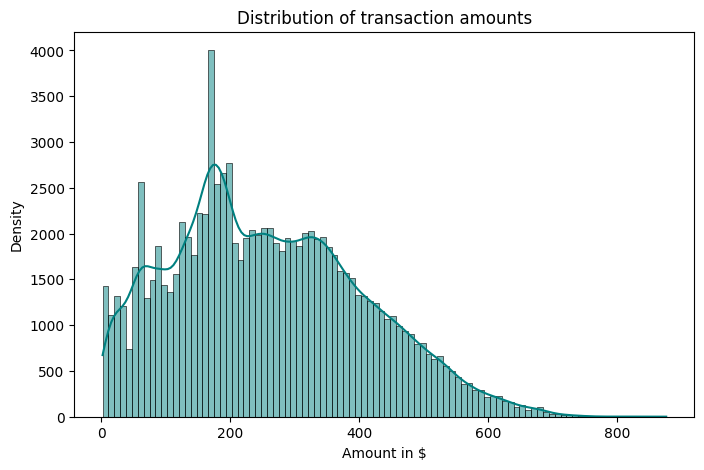

In [7]:
# Create a figure with specified size (width=8 inches, height=5 inches)
plt.figure(figsize=(8, 5))
sns.histplot(data=transactions, x='amount', kde=True, color='teal')

# Tags and title
plt.xlabel('Amount in $')
plt.ylabel('Density')
plt.title('Distribution of transaction amounts')
plt.show()

- Two numerical values

- One categorical variable

In [ ]:
# One categorical and one numerical variable (users with more then 80 transactions, exercise 1 SQL: 
# Make a subquery that shows all users with more than 80 transactions, using at least 2 tables.)

query = """
    SELECT u.id, COUNT(t.id) AS transactions_per_user
    FROM users AS u
    JOIN transactions AS t
    ON u.id = t.user_id
    GROUP BY u.id
    HAVING transactions_per_user >= 80;
    """

df_users_more_than_80_transactions = pd.read_sql(query, engine)
df_users_more_than_80_transactions

,id,transactions_per_user
0,185,110
1,289,94
2,318,91
3,454,81
